# Publication figure — exact recovered spatial graphs → saved recovered Yamada

This publication notebook does **not rerun skeletonization or graph recovery**.

It loads the exact post-cleanup recovered spatial graph saved by benchmark 04,
and displays only the `recovered_yamada` stored beside that same graph:

\[
\boxed{
G_{\rm recovered}^{\rm exact}
\longleftrightarrow
\Upsilon_{\rm recovered}
}
\]

A SHA-256 fingerprint is checked before plotting.

Styling follows `06_paper_scaling_publication_figure_final_push.ipynb`:
touching panel blocks, serif/STIX typography, KnottedGraph blue edges, enlarged
red junction vertices, black frames, intersection-anchored panel labels, and
high-resolution PNG/PDF export.


In [15]:

from __future__ import annotations

import copy
import gzip
import json
import math
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import sympy as sp
from matplotlib.patches import Rectangle
from skimage.measure import marching_cubes


def _is_knotted_graph_repo(candidate: Path) -> bool:
    return (
        (candidate / "pyproject.toml").exists()
        and (candidate / "src" / "knotted_graph").exists()
    )


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()
    checked: set[Path] = set()
    for candidate in (start, *start.parents):
        if candidate in checked:
            continue
        checked.add(candidate)
        if _is_knotted_graph_repo(candidate):
            return candidate
        for sibling_name in (
            "KnottedGraph_1earlier",
            "KnottedGraph_latest_git_for_codex",
            "KnottedGraph_latest_git",
        ):
            sibling = candidate / sibling_name
            if _is_knotted_graph_repo(sibling):
                return sibling
    raise RuntimeError(
        "Could not find the KnottedGraph repository root. "
        "Run this notebook from inside the repository checkout or FigureGeneration."
    )


ROOT = find_repo_root()

src_path = ROOT / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from knotted_graph.core import (
    contract_short_edges,
    ensure_embedding,
    remove_leaf_nodes,
    simplify_edges,
    smooth_edges,
)
from knotted_graph.extraction import (
    skeletonize_volume,
    topology_aware_skeleton_image_to_graph,
)
from knotted_graph.projection import compute_yamada_polynomial


BENCHMARK_DIR = ROOT / "User_guide" / "benchmarks"
FIGURE_GENERATION_DIR = ROOT / "FigureGeneration"
BENCHMARK_RESULTS_DIR = BENCHMARK_DIR / "results"
HANDLEBODY_DATA_DIR = BENCHMARK_RESULTS_DIR / "handlebody_ground_truth"
FIGURE_DIR = FIGURE_GENERATION_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Same publication styling as notebook 06
# ---------------------------------------------------------------------

KG_COLOR = "#2F5FB3"
TOPOLY_COLOR = "#111111"
ERROR_COLOR = "#C1121F"
VERTEX_COLOR = "#A60628"
EDGE_SHADOW_COLOR = "#0b3c5d"

PANEL_LABEL_FONT_SIZE = 26
AXIS_LABEL_FONT_SIZE = 30
TICK_FONT_SIZE = 24
LEGEND_FONT_SIZE = 20
AXIS_LINE_WIDTH = 1.9
SERIES_LINE_WIDTH = 3.2

FINAL_GRID_LINEWIDTH = 0.9
FINAL_GRID_COLOR = "black"
FINAL_GRID_PANEL_LABEL_FONT_SIZE = 26
FINAL_GRID_PANEL_LABEL_FONT_FAMILY = "serif"
FINAL_GRID_PANEL_LABEL_FONT_WEIGHT = "bold"

PDF_DPI = 700
PNG_DPI = 450

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "figure.dpi": 220,
    "font.size": 18,
    "axes.labelsize": AXIS_LABEL_FONT_SIZE,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE,
    "axes.linewidth": AXIS_LINE_WIDTH,
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "text.color": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": AXIS_LINE_WIDTH,
    "ytick.major.width": AXIS_LINE_WIDTH,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "savefig.facecolor": "white",
})

print("Repository:", ROOT)
print("Figure directory:", FIGURE_DIR)


Repository: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph_1earlier
Figure directory: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph_1earlier/FigureGeneration/figures


In [16]:

# ============================================================================
# USER CONTROLS
# ============================================================================

EMBEDDING_ARCHIVE_NAME = "certified_thick_handlebody_embeddings.json.gz"
RECOVERED_GRAPH_ARCHIVE_NAME = "synthetic_ground_truth_recovered_graphs.json.gz"

RESULTS_FILENAMES = (
    "synthetic_ground_truth_yamada_preservation.csv",
    "synthetic_ground_truth_results_checkpoint.csv",
)

# ------------------------------------------------------------------
# Figure grid controls
# ------------------------------------------------------------------
# N = number of case-rows.
# M = number of columns.
#
# Each case occupies:
#   row 2k     -> thick handlebody
#   row 2k + 1 -> recovered spatial graph + Yamada
#
# Therefore the final figure has:
#   TOTAL_PANEL_ROWS = 2 * N
#   TOTAL_PANEL_COLS = M
#
# Example:
#   N_CASE_ROWS = 4
#   N_CASE_COLS = 6
# gives an 8-row x 6-column panel figure and displays 24 cases.
N_CASE_ROWS = 5
N_CASE_COLS = 4

# If True, show only the spatial-graph+Yamada panels.
# If False, show the full latest version:
#   handlebody row + spatial-graph row for each case.
SPATIAL_GRAPH_ONLY = True

# Optional explicit selection.
# Must contain exactly N_CASE_ROWS * N_CASE_COLS case names.
# If None, the notebook auto-selects that many cases.
CASE_NAMES = None

# When automatically selecting examples, require the displayed Yamada
# polynomial to be different across different panels.
REQUIRE_DISTINCT_DISPLAY_YAMADA = True

# If True and there are not enough distinct-Yamada cases satisfying the
# display filters, raise an error instead of silently reusing a Yamada class.
STRICT_DISTINCT_YAMADA = True

# ------------------------------------------------------------------
# Automatic example-selection controls
# ------------------------------------------------------------------
# These affect only which saved certified cases are DISPLAYED.
# They do not change the benchmark or the saved archive.
#
# Strict visual-complexity window for automatically selected examples.
#
# IMPORTANT:
# These are now TRUE selection constraints, not merely preferences.
# Changing them changes the eligible case pool.
MIN_DISPLAY_CROSSINGS = 0
MAX_DISPLAY_CROSSINGS = 8

MIN_DISPLAY_GENUS = 1
MAX_DISPLAY_GENUS = 7

# Optional additional clutter controls.
MAX_DISPLAY_NODES = 14
MAX_DISPLAY_EDGES = 18

# When True, do NOT silently relax any of the bounds above.
# If there are not enough saved cases, the notebook raises a clear error.
STRICT_DISPLAY_FILTERS = True

# How to rank cases that pass the strict window.
#
# "near_limits":
#   choose cases close to MAX_DISPLAY_CROSSINGS / MAX_DISPLAY_GENUS.
#   This makes changing the max values visibly change the selected examples.
#
# "clearest":
#   choose the fewest crossings / lowest genus / fewest nodes.
DISPLAY_SELECTION_MODE = "near_limits"

# Canonical controls are OPTIONAL. If either is True, that panel is pinned
# and therefore will not change when you modify the filters.
KEEP_TRIVIAL_THETA = False
KEEP_TREFOIL_THETA = False

# Same production recovery parameters as benchmark 04.
MAX_JUNCTION_DEGREE = 3
ADAPTIVE_MAX_HOPS = 4
ANOMALY_RATIO = 0.15
CONTRACT_SHORT_EDGE_VOX = 1.75
SMOOTH_EPSILON_VOX = 1.5

# Legacy Yamada controls retained for compatibility; this figure does not recompute Yamada.
YAMADA_NUM_ROTATION_SAMPLES = 25
YAMADA_N_JOBS = 1

# ------------------------------------------------------------------
# Figure geometry — same publication feel as notebook 06
# ------------------------------------------------------------------

TOTAL_CASES = N_CASE_ROWS * N_CASE_COLS
TOTAL_PANEL_ROWS = N_CASE_ROWS if SPATIAL_GRAPH_ONLY else 2 * N_CASE_ROWS
TOTAL_PANEL_COLS = N_CASE_COLS

_mode_tag = "spatial_only" if SPATIAL_GRAPH_ONLY else "handlebody_plus_graph"
FIGURE_BASENAME = (
    f"07_handlebody_spatial_graph_yamada_{_mode_tag}_{TOTAL_PANEL_ROWS}x{TOTAL_PANEL_COLS}"
)

# Make the OUTER panel blocks square.
# This is especially useful for SPATIAL_GRAPH_ONLY=True.
PANEL_SIDE_IN = 3.25
FIG_WIDTH_IN = max(18.0, PANEL_SIDE_IN * TOTAL_PANEL_COLS)
FIG_HEIGHT_IN = max(5.3, PANEL_SIDE_IN * TOTAL_PANEL_ROWS)

GRID_LEFT = 0.018
GRID_RIGHT = 0.992
GRID_BOTTOM = 0.035
GRID_TOP = 0.972

# Blocks should touch exactly.
ROW_GAP = 0.0
COL_GAP = 0.0

CAMERA_EYE = np.array([1.2, 0.90, 1.3], dtype=float)

HANDLEBODY_SURFACE_ALPHA = 0.34
HANDLEBODY_SURFACE_COLOR = KG_COLOR
HANDLEBODY_MARCHING_CUBES_STEP = 2

SHOW_3D_BOXES = True
BOX_PADDING = 0.16
BOX_LINEWIDTH = 0.85

# ------------------------------------------------------------------
# Spatial-graph appearance controls
# ------------------------------------------------------------------
# Main blue edge thickness.
EDGE_SIZE = 3

# Extra width of the dark outline/shadow behind each blue edge.
# Set to 0.0 if you do not want the shadow to extend beyond the edge.
EDGE_SHADOW_EXTRA = 0.4

# Red marker size for ordinary graph vertices (degree < 3).
RED_VERTEX_SIZE = 100

# Red marker size for branching/intersection graph vertices (degree >= 3).
RED_BRANCH_VERTEX_SIZE = 100

# Derived shadow width; normally you only need to edit EDGE_SIZE and
# EDGE_SHADOW_EXTRA above.
GRAPH_SHADOW_LINEWIDTH = EDGE_SIZE + EDGE_SHADOW_EXTRA

YAMADA_FONT_SIZE = 17
YAMADA_DISPLAY_CHAR_LIMIT = 95
YAMADA_MAX_CHARS_PER_LINE = 54
ROW2_GRAPH_FRACTION = 0.76

# Panel label styling
PANEL_LABEL_FONT_SIZE = 24
# Put the label exactly on the box-corner intersection.
PANEL_LABEL_BOX_PAD = 0.15

PDF_DPI = 700
PNG_DPI = 450

print("Figure basename:", FIGURE_BASENAME)
print(f"Requested cases: {TOTAL_CASES} = {N_CASE_ROWS} x {N_CASE_COLS}")
print(f"Panel grid: {TOTAL_PANEL_ROWS} rows x {TOTAL_PANEL_COLS} cols")
print("Mode:", "spatial_graph_only" if SPATIAL_GRAPH_ONLY else "full handlebody + graph")
print("Require distinct displayed Yamada:", REQUIRE_DISTINCT_DISPLAY_YAMADA)

assert MIN_DISPLAY_CROSSINGS <= MAX_DISPLAY_CROSSINGS
assert MIN_DISPLAY_GENUS <= MAX_DISPLAY_GENUS
assert DISPLAY_SELECTION_MODE in {"near_limits", "clearest"}


Figure basename: 07_handlebody_spatial_graph_yamada_spatial_only_5x4
Requested cases: 20 = 5 x 4
Panel grid: 5 rows x 4 cols
Mode: spatial_graph_only
Require distinct displayed Yamada: True



## Load the exact certified embedding archive


In [17]:

def first_existing(paths):
    for path in paths:
        path = Path(path)

        if path.exists():
            return path

    return None


# ------------------------------------------------------------------
# Certified seed archive:
# used only when SPATIAL_GRAPH_ONLY=False to redraw the handlebody.
# ------------------------------------------------------------------
archive_path = first_existing(
    [
        HANDLEBODY_DATA_DIR / EMBEDDING_ARCHIVE_NAME,
        ROOT / EMBEDDING_ARCHIVE_NAME,
        BENCHMARK_DIR / EMBEDDING_ARCHIVE_NAME,
        BENCHMARK_DIR
        / "results"
        / EMBEDDING_ARCHIVE_NAME,
    ]
)

if archive_path is None:
    raise FileNotFoundError(
        f"Could not find {EMBEDDING_ARCHIVE_NAME}. "
        "Run benchmark 04 first."
    )

with gzip.open(
    archive_path,
    "rt",
    encoding="utf-8",
) as handle:
    archive = json.load(handle)

archive_records = archive["cases"]

archive_by_name = {
    record["case"]: record
    for record in archive_records
}


# ------------------------------------------------------------------
# Exact recovered graph archive:
# AUTHORITATIVE source for every plotted spatial graph and Yamada label.
# ------------------------------------------------------------------
recovered_archive_path = first_existing(
    [
        HANDLEBODY_DATA_DIR / RECOVERED_GRAPH_ARCHIVE_NAME,
        ROOT / RECOVERED_GRAPH_ARCHIVE_NAME,
        BENCHMARK_DIR
        / RECOVERED_GRAPH_ARCHIVE_NAME,
        BENCHMARK_DIR
        / "results"
        / RECOVERED_GRAPH_ARCHIVE_NAME,
    ]
)

if recovered_archive_path is None:
    raise FileNotFoundError(
        f"Could not find {RECOVERED_GRAPH_ARCHIVE_NAME}. "
        "Run the UPDATED benchmark 04 that saves exact recovered graphs."
    )

with gzip.open(
    recovered_archive_path,
    "rt",
    encoding="utf-8",
) as handle:
    recovered_archive = json.load(
        handle
    )

recovered_records = recovered_archive[
    "cases"
]

recovered_by_name = {
    record["case"]: record
    for record in recovered_records
}

print(
    "Certified seed archive:",
    archive_path,
)
print(
    "Certified seed cases:",
    len(archive_records),
)
print(
    "Exact recovered archive:",
    recovered_archive_path,
)
print(
    "Exact recovered graphs:",
    len(recovered_records),
)


Certified seed archive: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph_1earlier/User_guide/benchmarks/results/handlebody_ground_truth/certified_thick_handlebody_embeddings.json.gz
Certified seed cases: 520
Exact recovered archive: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph_1earlier/User_guide/benchmarks/results/handlebody_ground_truth/synthetic_ground_truth_recovered_graphs.json.gz
Exact recovered graphs: 100


In [18]:

def graph_from_serializable(
    payload: dict,
    *,
    ensure: bool = False,
) -> nx.MultiGraph:
    """
    Reconstruct a graph from archive data.

    For exact recovered graphs use ensure=False so no geometric normalization
    or cleanup is applied after loading.
    """
    graph = nx.MultiGraph()

    for node in payload["nodes"]:
        graph.add_node(
            node["id"],
            pos=np.asarray(
                node["pos"],
                dtype=float,
            ),
        )

    for edge in payload["edges"]:
        graph.add_edge(
            edge["u"],
            edge["v"],
            key=edge["key"],
            pts=np.asarray(
                edge["pts"],
                dtype=float,
            ),
        )

    if ensure:
        return ensure_embedding(
            graph
        )

    return graph


def graph_payload_sha256(
    payload: dict,
) -> str:
    import hashlib

    blob = json.dumps(
        payload,
        sort_keys=True,
        separators=(",", ":"),
        allow_nan=False,
    ).encode("utf-8")

    return hashlib.sha256(
        blob
    ).hexdigest()


def _record_crossings(
    record: dict,
) -> int:
    return int(
        record.get(
            "designed_crossings",
            0,
        )
        or 0
    )


def _record_genus(
    record: dict,
) -> int:
    return int(
        record.get(
            "graph_stats",
            {},
        ).get(
            "cycle_rank",
            0,
        )
        or 0
    )


def _record_nodes(
    record: dict,
) -> int:
    return int(
        record.get(
            "graph_stats",
            {},
        ).get(
            "nodes",
            0,
        )
        or 0
    )


def _record_edges(
    record: dict,
) -> int:
    return int(
        record.get(
            "graph_stats",
            {},
        ).get(
            "edges",
            0,
        )
        or 0
    )


def _record_radius_vox(
    record: dict,
) -> float:
    return float(
        record.get(
            "certification",
            {},
        ).get(
            "radius_vox",
            0.0,
        )
        or 0.0
    )


_A_SELECT = sp.Symbol("A")


def _parse_saved_yamada(
    value,
):
    if value is None:
        return None

    text = str(value).strip()

    if not text:
        return None

    try:
        expression = sp.expand(
            sp.sympify(
                text,
                locals={
                    "A": _A_SELECT,
                    "Y": _A_SELECT,
                },
            )
        )
    except Exception:
        return None

    return expression


def _exact_recovered_record(
    case_name: str,
):
    return recovered_by_name.get(
        case_name
    )


def _saved_recovered_yamada_expression(
    case_name: str,
):
    recovered_record = (
        _exact_recovered_record(
            case_name
        )
    )

    if recovered_record is None:
        return None

    return _parse_saved_yamada(
        recovered_record.get(
            "recovered_yamada"
        )
    )


def _saved_recovered_yamada_key(
    case_name: str,
):
    expression = (
        _saved_recovered_yamada_expression(
            case_name
        )
    )

    if expression is None:
        return None

    return str(
        sp.expand(
            expression
        )
    )


def _recovered_yamada_char_length(
    case_name: str,
) -> int:
    key = (
        _saved_recovered_yamada_key(
            case_name
        )
    )

    if key is None:
        return 10**9

    return len(
        key.replace(
            " ",
            "",
        )
    )


def _passes_display_filters(
    seed_record: dict,
) -> bool:
    x = _record_crossings(
        seed_record
    )
    g = _record_genus(
        seed_record
    )
    v = _record_nodes(
        seed_record
    )
    e = _record_edges(
        seed_record
    )

    return bool(
        MIN_DISPLAY_CROSSINGS
        <= x
        <= MAX_DISPLAY_CROSSINGS
        and MIN_DISPLAY_GENUS
        <= g
        <= MAX_DISPLAY_GENUS
        and v
        <= MAX_DISPLAY_NODES
        and e
        <= MAX_DISPLAY_EDGES
    )


def _selection_sort_key(
    seed_record: dict,
):
    x = _record_crossings(
        seed_record
    )
    g = _record_genus(
        seed_record
    )
    v = _record_nodes(
        seed_record
    )
    e = _record_edges(
        seed_record
    )
    r = _record_radius_vox(
        seed_record
    )

    if DISPLAY_SELECTION_MODE == "near_limits":
        return (
            abs(
                MAX_DISPLAY_CROSSINGS
                - x
            ),
            abs(
                MAX_DISPLAY_GENUS
                - g
            ),
            v,
            e,
            -r,
            seed_record["case"],
        )

    if DISPLAY_SELECTION_MODE == "clearest":
        return (
            x,
            g,
            v,
            e,
            -r,
            seed_record["case"],
        )

    raise ValueError(
        f"Unknown DISPLAY_SELECTION_MODE="
        f"{DISPLAY_SELECTION_MODE!r}"
    )


def _usable_exact_recovered(
    case_name: str,
) -> bool:
    """
    Publication-safe eligibility.

    Require:
      1. exact recovered graph record exists;
      2. recovered_yamada exists;
      3. recovered_yamada is paired to that graph's fingerprint;
      4. saved graph payload fingerprint verifies;
      5. benchmark case passed overall.
    """
    record = _exact_recovered_record(
        case_name
    )

    if record is None:
        return False

    payload = record.get(
        "recovered_graph"
    )

    if not payload:
        return False

    actual_hash = graph_payload_sha256(
        payload
    )

    saved_hash = record.get(
        "recovered_graph_sha256"
    )

    if actual_hash != saved_hash:
        return False

    yamada_expression = (
        _saved_recovered_yamada_expression(
            case_name
        )
    )

    if yamada_expression is None:
        return False

    if (
        record.get(
            "recovered_yamada_graph_sha256"
        )
        != actual_hash
    ):
        return False

    if not bool(
        record.get(
            "overall_pass",
            False,
        )
    ):
        return False

    return True


def choose_default_cases(
    records: list[dict],
    total_cases: int,
) -> list[str]:
    selected = []
    used_yamada_keys = set()

    pinned = []

    if KEEP_TRIVIAL_THETA:
        pinned.append(
            "control_trivial_theta"
        )

    if KEEP_TREFOIL_THETA:
        pinned.append(
            "control_trefoil_theta"
        )

    for name in pinned:
        if len(selected) >= total_cases:
            break

        if name not in archive_by_name:
            continue

        if not _usable_exact_recovered(
            name
        ):
            continue

        key = (
            _saved_recovered_yamada_key(
                name
            )
        )

        if (
            REQUIRE_DISTINCT_DISPLAY_YAMADA
            and key in used_yamada_keys
        ):
            continue

        selected.append(
            name
        )
        used_yamada_keys.add(
            key
        )

    eligible = [
        record
        for record in records
        if (
            record["case"]
            not in selected
            and _passes_display_filters(
                record
            )
            and _usable_exact_recovered(
                record["case"]
            )
        )
    ]

    eligible.sort(
        key=_selection_sort_key
    )

    print(
        "Publication-safe eligible cases:",
        len(eligible),
        "for",
        total_cases - len(selected),
        "open slots",
    )

    for record in eligible:
        if len(selected) >= total_cases:
            break

        name = record["case"]
        key = (
            _saved_recovered_yamada_key(
                name
            )
        )

        if (
            REQUIRE_DISTINCT_DISPLAY_YAMADA
            and key in used_yamada_keys
        ):
            continue

        selected.append(
            name
        )
        used_yamada_keys.add(
            key
        )

    if len(selected) != total_cases:
        raise RuntimeError(
            "Not enough publication-safe exact recovered graphs satisfy "
            "the current display filters and distinct-Yamada requirement.\n"
            f"Needed {total_cases}, selected {len(selected)}.\n"
            "Relax the display filters or run benchmark 04 on more cases."
        )

    return selected


if CASE_NAMES is None:
    selected_case_names = (
        choose_default_cases(
            archive_records,
            TOTAL_CASES,
        )
    )
else:
    selected_case_names = list(
        CASE_NAMES
    )

if (
    len(selected_case_names)
    != TOTAL_CASES
):
    raise ValueError(
        "CASE_NAMES must contain exactly "
        f"TOTAL_CASES={TOTAL_CASES} names."
    )

for name in selected_case_names:
    if name not in archive_by_name:
        raise KeyError(
            f"Selected seed case {name!r} "
            "is absent from the certified archive."
        )

    if not _usable_exact_recovered(
        name
    ):
        raise RuntimeError(
            f"Selected case {name!r} does not have a publication-safe "
            "exact recovered graph + recovered_yamada pair."
        )


# ------------------------------------------------------------------
# Final publication order:
# shortest FULL saved recovered_yamada -> longest.
# ------------------------------------------------------------------
selected_case_names = sorted(
    selected_case_names,
    key=lambda name: (
        _recovered_yamada_char_length(
            name
        ),
        name,
    ),
)


selected_table = []

for slot, name in enumerate(
    selected_case_names,
    start=1,
):
    seed_record = archive_by_name[
        name
    ]
    recovered_record = (
        recovered_by_name[
            name
        ]
    )

    selected_table.append(
        {
            "slot": slot,
            "case": name,
            "family": seed_record.get(
                "embedding_family"
            ),
            "crossings": _record_crossings(
                seed_record
            ),
            "genus": _record_genus(
                seed_record
            ),
            "nodes": recovered_record[
                "recovered_graph_stats"
            ]["nodes"],
            "edges": recovered_record[
                "recovered_graph_stats"
            ]["edges"],
            "radius_vox": _record_radius_vox(
                seed_record
            ),
            "recovered_yamada_chars": (
                _recovered_yamada_char_length(
                    name
                )
            ),
            "recovered_graph_sha256": (
                recovered_record[
                    "recovered_graph_sha256"
                ][:12]
            ),
            "recovered_yamada": (
                _saved_recovered_yamada_key(
                    name
                )
            ),
        }
    )

selected_table = pd.DataFrame(
    selected_table
)

print(
    "Selected exact recovered graphs "
    "(shortest -> longest recovered Yamada):"
)
display(
    selected_table
)

if REQUIRE_DISTINCT_DISPLAY_YAMADA:
    assert (
        selected_table[
            "recovered_yamada"
        ].nunique()
        == len(
            selected_table
        )
    )

print(
    "All displayed graph/Yamada fingerprints verified."
)


Publication-safe eligible cases: 85 for 20 open slots
Selected exact recovered graphs (shortest -> longest recovered Yamada):


,slot,case,family,crossings,genus,nodes,edges,radius_vox,recovered_yamada_chars,recovered_graph_sha256,recovered_yamada
0,1,random_0031,crossing_rich,6,6,4,6,5.621055,35,cbf3fad76e45,-A**6 - A**5 - 3*A**4 - 2*A**3 - 3*A**2 - A - 1
1,2,random_0005,crossing_rich,6,6,6,9,5.221079,43,7f83fd756d4e,2*A**7 - A**6 + 4*A**5 - 3*A**4 + 3*A**3 - 4*A...
2,3,random_0014,crossing_rich,8,7,6,9,4.876097,49,a5737bf10513,-A**8 + A**7 - 3*A**6 + 2*A**5 - 4*A**4 + 2*A*...
3,4,random_0086,crossing_rich,5,6,6,9,4.037108,49,a7646467c034,-A**8 - A**7 - 4*A**6 - 3*A**5 - 6*A**4 - 3*A*...
4,5,random_0088,crossing_rich,6,6,8,12,4.165146,66,3554203f13c6,-A**10 - A**9 - 5*A**8 - 4*A**7 - 10*A**6 - 6*...
5,6,random_0082,crossing_rich,4,5,8,12,4.758171,68,1daffe71f68b,-A**10 + 2*A**9 - 5*A**8 + 6*A**7 - 9*A**6 + 8...
6,7,random_0036,crossing_rich,4,5,8,12,5.396144,70,4f1b83b87701,-A**10 + 2*A**9 - 7*A**8 + 5*A**7 - 14*A**6 + ...
7,8,random_0026,crossing_rich,4,5,8,12,5.503390,78,089d84f99133,A**12 + A**11 - A**10 + 7*A**9 - 7*A**8 + 13*A...
8,9,random_0043,crossing_rich,2,4,8,12,5.836994,81,5cc16f5430f1,A**12 + A**11 + A**10 + 7*A**9 - 4*A**8 + 13*A...
9,10,random_0044,crossing_rich,3,5,8,12,4.909098,81,7c2b38cdc07d,A**12 + 2*A**11 - 2*A**10 + 8*A**9 - 8*A**8 + ...


All displayed graph/Yamada fingerprints verified.


In [19]:

_exact_good = [
    name
    for name in archive_by_name
    if _usable_exact_recovered(
        name
    )
]

print(
    "Publication-safe exact recovered graph + Yamada pairs:",
    len(_exact_good),
    "/",
    len(archive_records),
)


Publication-safe exact recovered graph + Yamada pairs: 96 / 520


## Load exact recovered graphs; reconstruct handlebodies only if requested

No skeletonization, graph extraction, contraction, simplification, smoothing, or
Yamada computation occurs in this notebook.

- spatial graph: loaded exactly from `synthetic_ground_truth_recovered_graphs.json.gz`;
- Yamada: loaded from the same recovered-graph record;
- optional handlebody: reconstructed from the certified seed graph only for visualization when `SPATIAL_GRAPH_ONLY=False`.


In [20]:

def voxelize_regular_neighborhood(
    graph: nx.MultiGraph,
    radius: float,
    grid_size: int,
    *,
    margin_radii: float = 2.25,
):
    """
    Reconstruct the certified thick input only for visualization.

    This function is never used to regenerate the displayed spatial graph.
    """
    all_points = np.concatenate(
        [
            np.asarray(
                data["pts"],
                dtype=float,
            )
            for _, _, _, data
            in graph.edges(
                keys=True,
                data=True,
            )
        ],
        axis=0,
    )

    max_norm = float(
        np.max(
            np.linalg.norm(
                all_points,
                axis=1,
            )
        )
    )

    half_extent = (
        max_norm
        + margin_radii
        * radius
    )

    origin = np.array(
        [
            -half_extent,
            -half_extent,
            -half_extent,
        ],
        dtype=float,
    )

    spacing = (
        2.0
        * half_extent
        / (
            grid_size
            - 1
        )
    )

    volume = np.zeros(
        (
            grid_size,
            grid_size,
            grid_size,
        ),
        dtype=bool,
    )

    for _, _, _, data in graph.edges(
        keys=True,
        data=True,
    ):
        polyline = np.asarray(
            data["pts"],
            dtype=float,
        )

        for a, b in zip(
            polyline[:-1],
            polyline[1:],
        ):
            lower = np.floor(
                (
                    np.minimum(
                        a,
                        b,
                    )
                    - radius
                    - origin
                )
                / spacing
            ).astype(int)

            upper = np.ceil(
                (
                    np.maximum(
                        a,
                        b,
                    )
                    + radius
                    - origin
                )
                / spacing
            ).astype(int)

            lower = np.maximum(
                lower,
                0,
            )

            upper = np.minimum(
                upper,
                grid_size - 1,
            )

            if np.any(
                lower > upper
            ):
                continue

            sx = slice(
                lower[0],
                upper[0] + 1,
            )
            sy = slice(
                lower[1],
                upper[1] + 1,
            )
            sz = slice(
                lower[2],
                upper[2] + 1,
            )

            x = (
                origin[0]
                + spacing
                * np.arange(
                    lower[0],
                    upper[0] + 1,
                )[:, None, None]
            )

            y = (
                origin[1]
                + spacing
                * np.arange(
                    lower[1],
                    upper[1] + 1,
                )[None, :, None]
            )

            z = (
                origin[2]
                + spacing
                * np.arange(
                    lower[2],
                    upper[2] + 1,
                )[None, None, :]
            )

            ab = b - a
            denominator = float(
                ab @ ab
            )

            if denominator <= 1e-20:
                distance_squared = (
                    (x - a[0]) ** 2
                    + (y - a[1]) ** 2
                    + (z - a[2]) ** 2
                )
            else:
                t = (
                    (x - a[0])
                    * ab[0]
                    + (y - a[1])
                    * ab[1]
                    + (z - a[2])
                    * ab[2]
                ) / denominator

                t = np.clip(
                    t,
                    0.0,
                    1.0,
                )

                cx = (
                    a[0]
                    + t
                    * ab[0]
                )
                cy = (
                    a[1]
                    + t
                    * ab[1]
                )
                cz = (
                    a[2]
                    + t
                    * ab[2]
                )

                distance_squared = (
                    (x - cx) ** 2
                    + (y - cy) ** 2
                    + (z - cz) ** 2
                )

            volume[
                sx,
                sy,
                sz,
            ] |= (
                distance_squared
                <= radius
                * radius
            )

    return (
        volume,
        origin,
        float(spacing),
        float(half_extent),
    )


A = sp.Symbol("A")

display_records = []

grid_size = int(
    archive.get(
        "config",
        {},
    ).get(
        "GRID_SIZE",
        200,
    )
)

for case_name in selected_case_names:
    seed_record = archive_by_name[
        case_name
    ]

    recovered_record = (
        recovered_by_name[
            case_name
        ]
    )

    # --------------------------------------------------------------
    # AUTHORITATIVE displayed spatial graph:
    # exact graph serialized by benchmark 04 immediately after cleanup.
    # --------------------------------------------------------------
    recovered_payload = (
        recovered_record[
            "recovered_graph"
        ]
    )

    actual_hash = (
        graph_payload_sha256(
            recovered_payload
        )
    )

    saved_hash = (
        recovered_record[
            "recovered_graph_sha256"
        ]
    )

    yamada_hash = (
        recovered_record[
            "recovered_yamada_graph_sha256"
        ]
    )

    assert (
        actual_hash
        == saved_hash
        == yamada_hash
    ), (
        f"Graph/Yamada fingerprint mismatch for "
        f"{case_name}"
    )

    recovered_graph = (
        graph_from_serializable(
            recovered_payload,
            ensure=False,
        )
    )

    yamada = (
        _saved_recovered_yamada_expression(
            case_name
        )
    )

    if yamada is None:
        raise RuntimeError(
            f"Missing recovered_yamada for "
            f"{case_name}"
        )

    # --------------------------------------------------------------
    # Optional handlebody visualization.
    # This does NOT influence the displayed recovered graph.
    # --------------------------------------------------------------
    volume = None
    origin = None
    spacing = None

    if not SPATIAL_GRAPH_ONLY:
        seed_graph = (
            graph_from_serializable(
                seed_record[
                    "embedding"
                ],
                ensure=True,
            )
        )

        radius = float(
            seed_record[
                "certification"
            ][
                "radius_world"
            ]
        )

        (
            volume,
            origin,
            spacing,
            half_extent,
        ) = voxelize_regular_neighborhood(
            seed_graph,
            radius,
            grid_size,
        )

    display_records.append(
        {
            "case": case_name,
            "seed_record": seed_record,
            "recovered_record": (
                recovered_record
            ),
            "volume": volume,
            "origin": origin,
            "spacing": spacing,
            "recovered_graph": (
                recovered_graph
            ),
            "yamada": yamada,
            "yamada_source": (
                "exact recovered archive"
            ),
            "graph_sha256": (
                actual_hash
            ),
        }
    )

    print(
        f"{case_name}: "
        f"V={recovered_graph.number_of_nodes()}, "
        f"E={recovered_graph.number_of_edges()}, "
        f"graph={actual_hash[:12]}, "
        "Yamada=paired saved recovered_yamada"
    )


random_0031: V=4, E=6, graph=cbf3fad76e45, Yamada=paired saved recovered_yamada
random_0005: V=6, E=9, graph=7f83fd756d4e, Yamada=paired saved recovered_yamada
random_0014: V=6, E=9, graph=a5737bf10513, Yamada=paired saved recovered_yamada
random_0086: V=6, E=9, graph=a7646467c034, Yamada=paired saved recovered_yamada
random_0088: V=8, E=12, graph=3554203f13c6, Yamada=paired saved recovered_yamada
random_0082: V=8, E=12, graph=1daffe71f68b, Yamada=paired saved recovered_yamada
random_0036: V=8, E=12, graph=4f1b83b87701, Yamada=paired saved recovered_yamada
random_0026: V=8, E=12, graph=089d84f99133, Yamada=paired saved recovered_yamada
random_0043: V=8, E=12, graph=5cc16f5430f1, Yamada=paired saved recovered_yamada
random_0044: V=8, E=12, graph=7c2b38cdc07d, Yamada=paired saved recovered_yamada
random_0001: V=6, E=9, graph=5582c8ec6e22, Yamada=paired saved recovered_yamada
random_0090: V=10, E=15, graph=c7a7e85a9430, Yamada=paired saved recovered_yamada
random_0027: V=10, E=15, graph=7


## Publication renderer


Saved PNG: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph_1earlier/FigureGeneration/figures/07_handlebody_spatial_graph_yamada_spatial_only_5x4.png
Saved PDF: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph_1earlier/FigureGeneration/figures/07_handlebody_spatial_graph_yamada_spatial_only_5x4.pdf


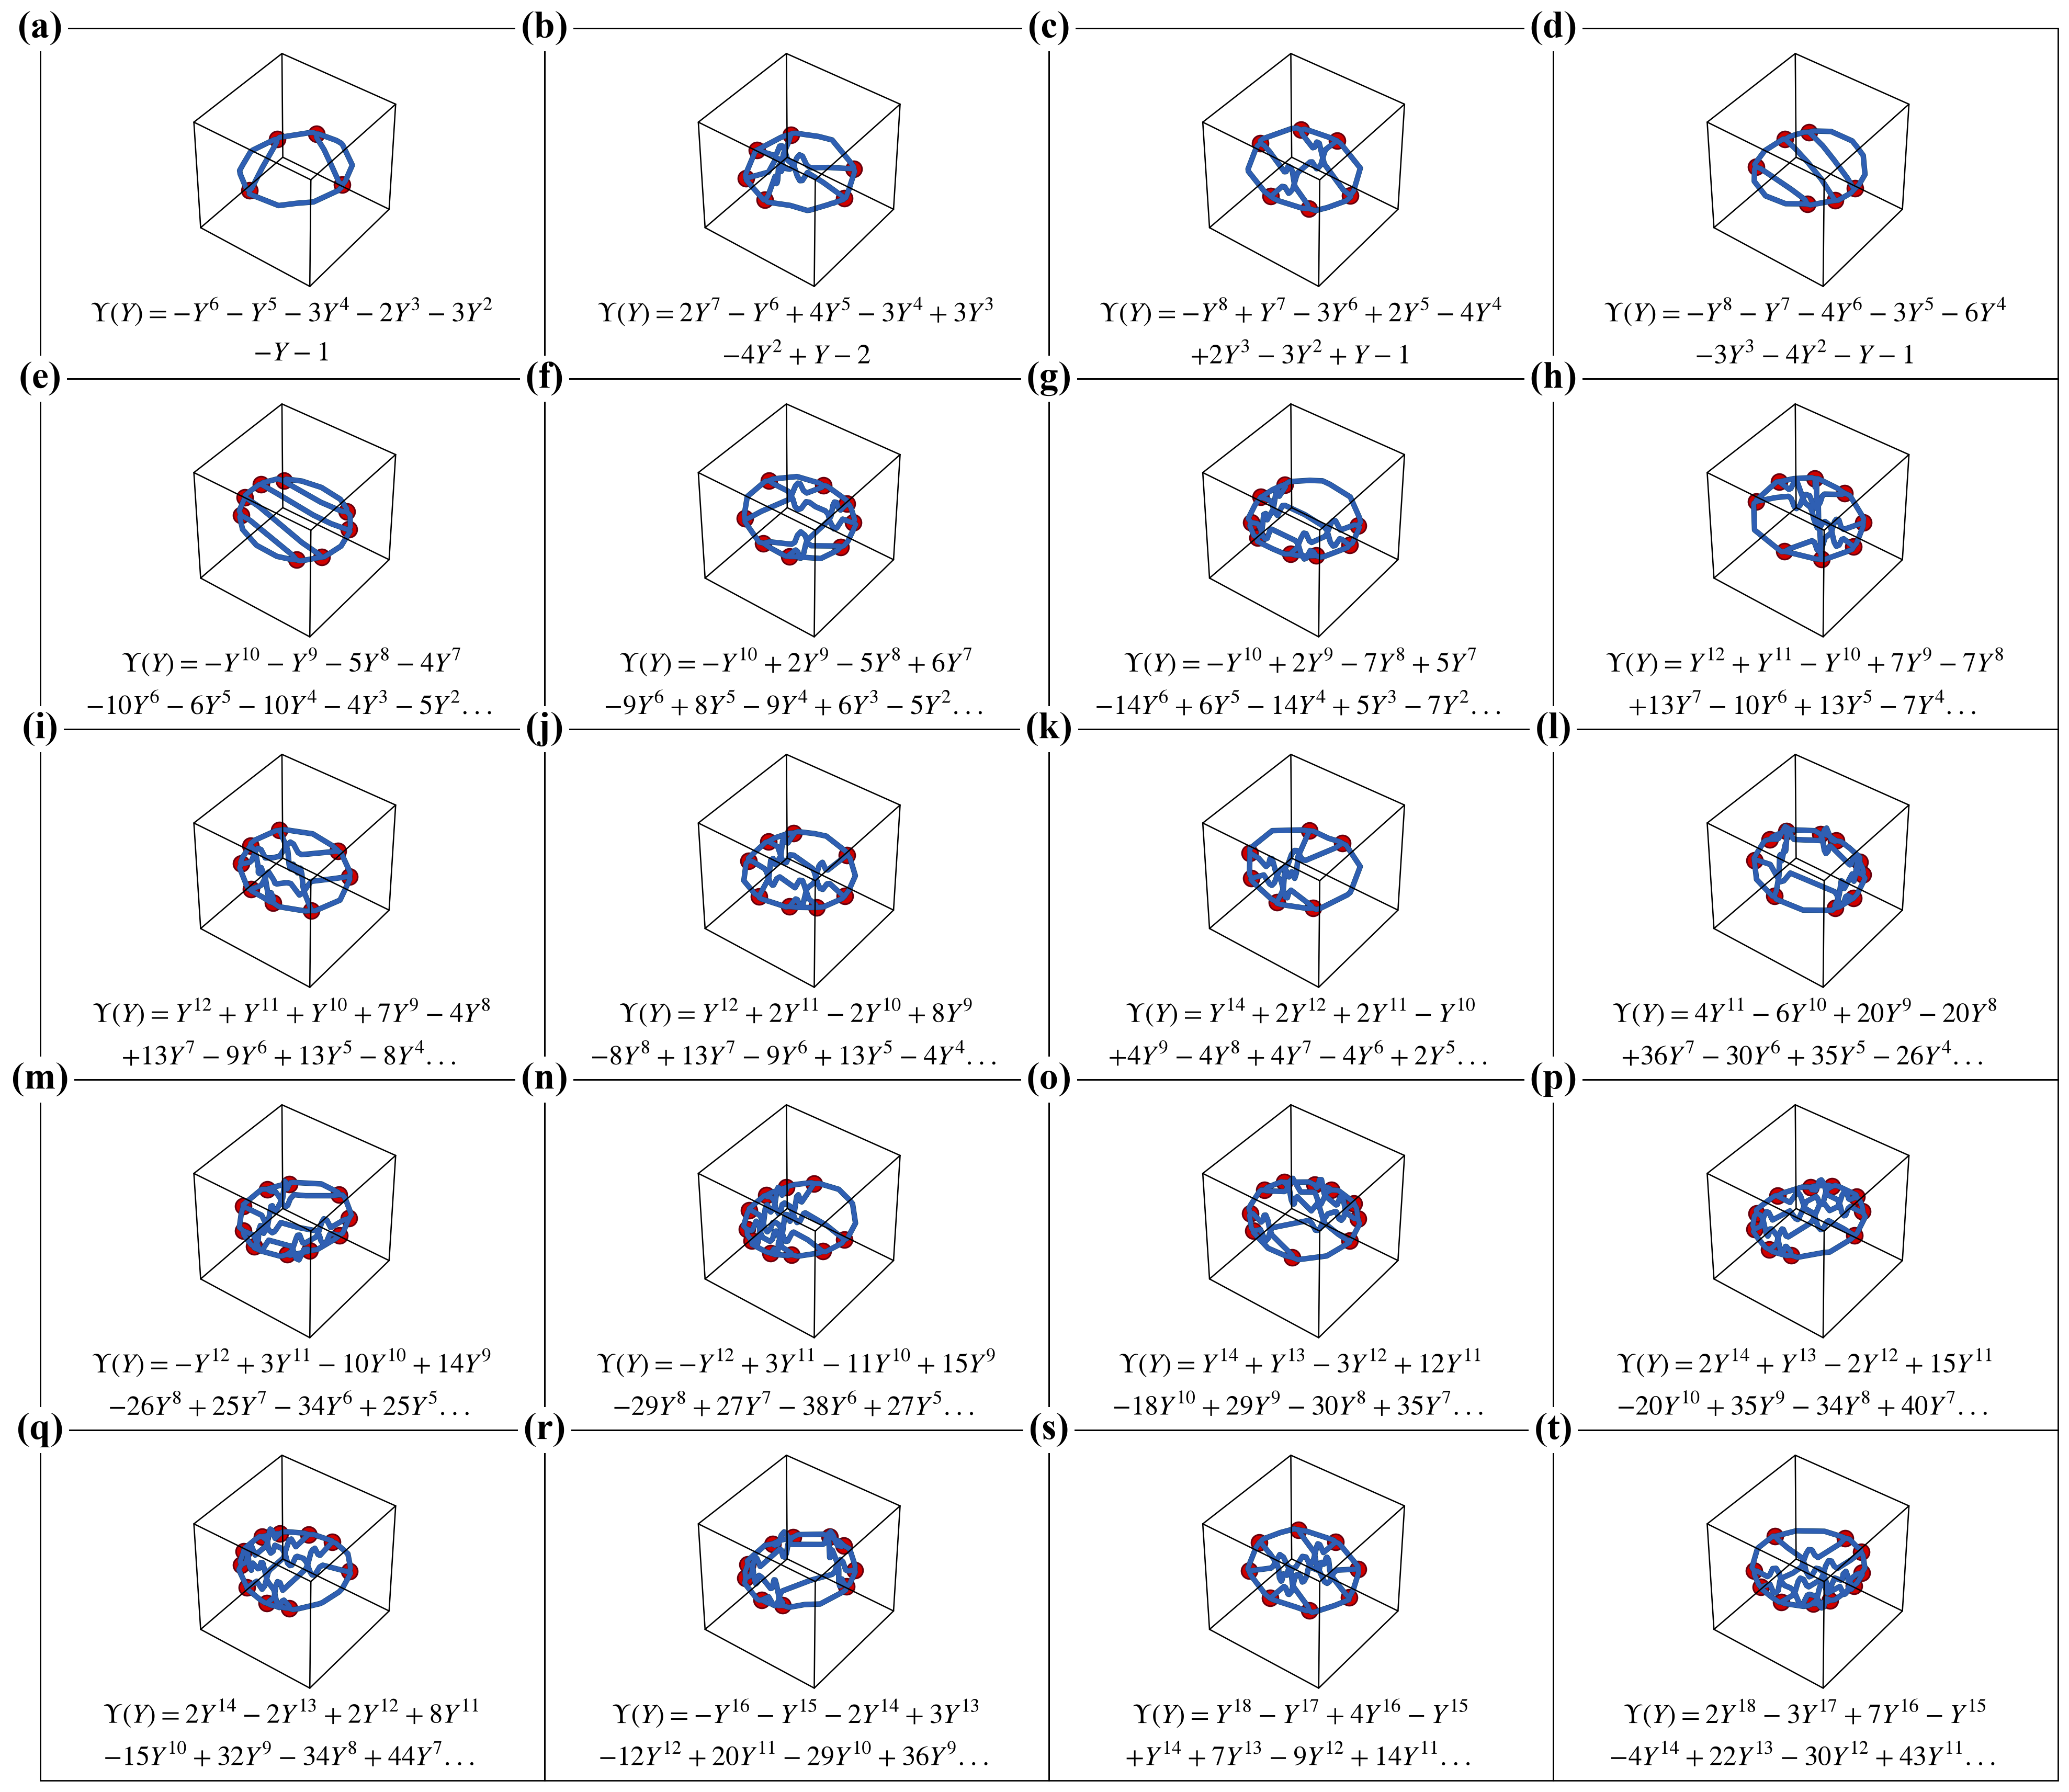

In [21]:

def all_graph_xyz(
    graph: nx.MultiGraph,
) -> np.ndarray:
    arrays = []

    for _, data in graph.nodes(
        data=True,
    ):
        if "pos" in data:
            arrays.append(
                np.asarray(
                    data["pos"],
                    dtype=float,
                )[None, :]
            )

    for _, _, _, data in graph.edges(
        keys=True,
        data=True,
    ):
        if "pts" in data:
            arrays.append(
                np.asarray(
                    data["pts"],
                    dtype=float,
                )
            )

    if not arrays:
        return np.empty(
            (0, 3),
            dtype=float,
        )

    return np.vstack(
        arrays
    )


def set_equal_3d_limits(
    ax,
    points: np.ndarray,
    *,
    padding_fraction: float = 0.14,
):
    points = np.asarray(
        points,
        dtype=float,
    )

    points = points[
        np.isfinite(
            points
        ).all(axis=1)
    ]

    lo = points.min(
        axis=0
    )
    hi = points.max(
        axis=0
    )

    center = 0.5 * (
        lo + hi
    )

    dominant = max(
        float(
            np.max(
                hi - lo
            )
        ),
        1e-8,
    )

    half = (
        0.5
        * dominant
        * (
            1.0
            + 2.0
            * padding_fraction
        )
    )

    ax.set_xlim(
        center[0] - half,
        center[0] + half,
    )
    ax.set_ylim(
        center[1] - half,
        center[1] + half,
    )
    ax.set_zlim(
        center[2] - half,
        center[2] + half,
    )

    ax.set_box_aspect(
        (1, 1, 1)
    )

    return center, half


def camera_elev_azim(
    eye: np.ndarray,
):
    eye = np.asarray(
        eye,
        dtype=float,
    )

    xy = math.hypot(
        float(eye[0]),
        float(eye[1]),
    )

    elev = math.degrees(
        math.atan2(
            float(eye[2]),
            xy,
        )
    )

    azim = -math.degrees(
        math.atan2(
            float(eye[0]),
            float(eye[1]),
        )
    )

    return elev, azim


CAMERA_ELEV, CAMERA_AZIM = (
    camera_elev_azim(
        CAMERA_EYE
    )
)


def draw_bounding_box(
    ax,
    center: np.ndarray,
    half: float,
):
    if not SHOW_3D_BOXES:
        return

    box_half = (
        half
        * (1.0 - 0.055)
    )

    lo = (
        center
        - box_half
    )
    hi = (
        center
        + box_half
    )

    corners = np.array(
        [
            [lo[0], lo[1], lo[2]],
            [hi[0], lo[1], lo[2]],
            [hi[0], hi[1], lo[2]],
            [lo[0], hi[1], lo[2]],
            [lo[0], lo[1], hi[2]],
            [hi[0], lo[1], hi[2]],
            [hi[0], hi[1], hi[2]],
            [lo[0], hi[1], hi[2]],
        ],
        dtype=float,
    )

    edges = (
        (0, 1), (1, 2),
        (2, 3), (3, 0),
        (4, 5), (5, 6),
        (6, 7), (7, 4),
        (0, 4), (1, 5),
        (2, 6), (3, 7),
    )

    for a, b in edges:
        segment = corners[
            [a, b]
        ]

        ax.plot(
            segment[:, 0],
            segment[:, 1],
            segment[:, 2],
            color="black",
            linewidth=BOX_LINEWIDTH,
            solid_capstyle="round",
            zorder=20,
        )


def clean_3d_axis(ax):
    ax.set_axis_off()
    ax.set_facecolor(
        "white"
    )

    ax.view_init(
        elev=CAMERA_ELEV,
        azim=CAMERA_AZIM,
    )


def draw_handlebody(
    ax,
    volume: np.ndarray,
    origin: np.ndarray,
    spacing: float,
):
    (
        verts,
        faces,
        _,
        _,
    ) = marching_cubes(
        volume.astype(
            np.float32
        ),
        level=0.5,
        spacing=(
            spacing,
            spacing,
            spacing,
        ),
        step_size=HANDLEBODY_MARCHING_CUBES_STEP,
        allow_degenerate=False,
    )

    verts = (
        verts
        + np.asarray(
            origin,
            dtype=float,
        )
    )

    ax.plot_trisurf(
        verts[:, 0],
        verts[:, 1],
        faces,
        verts[:, 2],
        color=HANDLEBODY_SURFACE_COLOR,
        alpha=HANDLEBODY_SURFACE_ALPHA,
        linewidth=0.0,
        antialiased=True,
        shade=True,
        rasterized=True,
    )

    center, half = (
        set_equal_3d_limits(
            ax,
            verts,
            padding_fraction=BOX_PADDING,
        )
    )

    draw_bounding_box(
        ax,
        center,
        half,
    )

    clean_3d_axis(
        ax
    )


def draw_spatial_graph(
    ax,
    graph: nx.MultiGraph,
):
    points = all_graph_xyz(
        graph
    )

    for _, _, _, data in graph.edges(
        keys=True,
        data=True,
    ):
        pts = np.asarray(
            data["pts"],
            dtype=float,
        )

        if len(pts) < 2:
            continue

        ax.plot(
            pts[:, 0],
            pts[:, 1],
            pts[:, 2],
            color=EDGE_SHADOW_COLOR,
            linewidth=GRAPH_SHADOW_LINEWIDTH,
            solid_capstyle="round",
            zorder=3,
        )

        ax.plot(
            pts[:, 0],
            pts[:, 1],
            pts[:, 2],
            color=KG_COLOR,
            linewidth=EDGE_SIZE,
            solid_capstyle="round",
            zorder=4,
        )

    regular_xyz = []
    regular_sizes = []
    intersection_xyz = []

    degrees = dict(graph.degree())

    for node, data in graph.nodes(data=True):
        if "pos" not in data:
            continue

        pos = np.asarray(
            data["pos"],
            dtype=float,
        )

        if degrees.get(node, 0) >= 3:
            intersection_xyz.append(pos)
        else:
            regular_xyz.append(pos)
            regular_sizes.append(RED_VERTEX_SIZE)

    if regular_xyz:
        regular_xyz = np.vstack(regular_xyz)
        ax.scatter(
            regular_xyz[:, 0],
            regular_xyz[:, 1],
            regular_xyz[:, 2],
            s=RED_VERTEX_SIZE,
            c=VERTEX_COLOR,
            edgecolors="#7f1d1d",
            linewidths=0.7,
            depthshade=False,
            zorder=6,
        )

    if intersection_xyz:
        intersection_xyz = np.vstack(intersection_xyz)
        ax.scatter(
            intersection_xyz[:, 0],
            intersection_xyz[:, 1],
            intersection_xyz[:, 2],
            s=RED_BRANCH_VERTEX_SIZE,
            c="#D00000",
            edgecolors="#67000d",
            linewidths=1.0,
            depthshade=False,
            zorder=7,
        )

    center, half = (
        set_equal_3d_limits(
            ax,
            points,
            padding_fraction=BOX_PADDING,
        )
    )

    draw_bounding_box(
        ax,
        center,
        half,
    )

    clean_3d_axis(
        ax
    )


def laurent_terms(
    expression,
    variable,
):
    expression = sp.expand(
        expression
    )

    terms = []

    for term in sp.Add.make_args(
        expression
    ):
        power = sp.sympify(
            term.as_powers_dict().get(
                variable,
                0,
            )
        )

        coefficient = sp.simplify(
            term
            / (
                variable
                ** power
            )
        )

        try:
            power_key = float(
                power
            )
        except Exception:
            power_key = 0.0

        terms.append(
            (
                power_key,
                power,
                coefficient,
            )
        )

    terms.sort(
        key=lambda item: item[0],
        reverse=True,
    )

    return terms


def term_latex(
    coefficient,
    power,
    variable,
    *,
    first: bool,
):
    coefficient = sp.simplify(
        coefficient
    )

    negative = bool(
        coefficient.could_extract_minus_sign()
    )

    magnitude = (
        -coefficient
        if negative
        else coefficient
    )

    if power == 0:
        body = sp.latex(
            magnitude
        )
    else:
        coeff_text = (
            ""
            if magnitude == 1
            else sp.latex(
                magnitude
            )
        )

        if power == 1:
            variable_text = sp.latex(
                variable
            )
        else:
            variable_text = (
                f"{sp.latex(variable)}"
                f"^{{{sp.latex(power)}}}"
            )

        body = (
            coeff_text
            + variable_text
        )

    if first:
        return (
            ("-" if negative else "")
            + body
        )

    return (
        (" - " if negative else " + ")
        + body
    )


Y_DISPLAY = sp.Symbol("Y")


def yamada_math_lines(
    expression,
):
    expression = sp.expand(
        sp.sympify(expression).subs(A, Y_DISPLAY)
    )

    terms = laurent_terms(
        expression,
        Y_DISPLAY,
    )

    pieces = [
        term_latex(
            coefficient,
            power,
            Y_DISPLAY,
            first=(index == 0),
        )
        for index, (_, power, coefficient) in enumerate(terms)
    ]

    prefix = r"\Upsilon(Y)="
    lines = []
    current = prefix
    total_chars = len(prefix)
    truncated = False

    for piece in pieces:
        piece_len = len(piece)

        if total_chars + piece_len > YAMADA_DISPLAY_CHAR_LIMIT:
            if current == prefix:
                # Even the first term is too long: cut the piece directly.
                remaining = max(0, YAMADA_DISPLAY_CHAR_LIMIT - len(prefix) - 3)
                current = prefix + piece[:remaining] + "..."
            else:
                current = current + "..."
            truncated = True
            break

        proposed = current + piece

        if (
            len(proposed) > YAMADA_MAX_CHARS_PER_LINE
            and current != prefix
        ):
            lines.append(current)
            current = piece.lstrip()
        else:
            current = proposed

        total_chars += piece_len

    if current:
        lines.append(current)

    return lines


def draw_yamada_text(
    ax,
    expression,
):
    ax.set_axis_off()
    ax.set_facecolor(
        "white"
    )

    lines = yamada_math_lines(
        expression
    )

    if len(lines) <= 2:
        font_size = (
            YAMADA_FONT_SIZE
        )
    elif len(lines) == 3:
        font_size = (
            YAMADA_FONT_SIZE
            - 1
        )
    else:
        font_size = max(
            12,
            YAMADA_FONT_SIZE
            - 3,
        )

    y_positions = np.linspace(
        0.76,
        0.18,
        len(lines),
    )

    for y, line in zip(
        y_positions,
        lines,
    ):
        ax.text(
            0.5,
            float(y),
            f"${line}$",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=font_size,
            color="black",
            fontfamily="serif",
        )


def panel_bounds(
    col: int,
    panel_row: int,
):
    total_width = (
        GRID_RIGHT
        - GRID_LEFT
    )

    col_width = (
        total_width
        - (
            TOTAL_PANEL_COLS - 1
        ) * COL_GAP
    ) / TOTAL_PANEL_COLS

    total_height = (
        GRID_TOP
        - GRID_BOTTOM
    )

    row_height = (
        total_height
        - (
            TOTAL_PANEL_ROWS - 1
        ) * ROW_GAP
    ) / TOTAL_PANEL_ROWS

    x0 = (
        GRID_LEFT
        + col
        * (
            col_width
            + COL_GAP
        )
    )
    x1 = (
        x0
        + col_width
    )

    # panel_row = 0 is the topmost panel row.
    y1 = (
        GRID_TOP
        - panel_row
        * (
            row_height
            + ROW_GAP
        )
    )
    y0 = (
        y1
        - row_height
    )

    return (
        x0,
        y0,
        x1,
        y1,
    )


fig = plt.figure(
    figsize=(
        FIG_WIDTH_IN,
        FIG_HEIGHT_IN,
    ),
    facecolor="white",
)

axes_top = []
axes_bottom_graph = []
axes_bottom_text = []

# Build either:
#   - the full 2N x M layout, or
#   - the spatial-graph-only N x M layout.
for case_row in range(
    N_CASE_ROWS
):
    for col in range(
        N_CASE_COLS
    ):
        # Very small inner padding so frames touch exactly.
        pad_x = 0.006
        pad_y = 0.010

        if not SPATIAL_GRAPH_ONLY:
            # Top panel for this case: handlebody.
            top_panel_row = 2 * case_row
            x0, y0, x1, y1 = panel_bounds(
                col,
                top_panel_row,
            )

            top_ax = fig.add_axes(
                [
                    x0 + pad_x,
                    y0 + pad_y,
                    (
                        x1 - x0
                        - 2 * pad_x
                    ),
                    (
                        y1 - y0
                        - 2 * pad_y
                    ),
                ],
                projection="3d",
            )
            axes_top.append(top_ax)

            # Bottom panel for the same case: graph + Yamada.
            bottom_panel_row = 2 * case_row + 1
            xb0, yb0, xb1, yb1 = panel_bounds(
                col,
                bottom_panel_row,
            )
        else:
            # Single panel for this case: graph + Yamada only.
            xb0, yb0, xb1, yb1 = panel_bounds(
                col,
                case_row,
            )

        panel_h = yb1 - yb0

        graph_y0 = (
            yb0
            + panel_h
            * (
                1.0
                - ROW2_GRAPH_FRACTION
            )
        )

        graph_h = (
            panel_h
            * ROW2_GRAPH_FRACTION
        )

        graph_ax = fig.add_axes(
            [
                xb0 + pad_x,
                graph_y0,
                (
                    xb1 - xb0
                    - 2 * pad_x
                ),
                graph_h - pad_y,
            ],
            projection="3d",
        )

        text_ax = fig.add_axes(
            [
                xb0 + 0.012,
                yb0 + 0.006,
                (
                    xb1 - xb0
                    - 0.024
                ),
                (
                    panel_h
                    * (
                        1.0
                        - ROW2_GRAPH_FRACTION
                    )
                    - 0.006
                ),
            ]
        )

        axes_bottom_graph.append(graph_ax)
        axes_bottom_text.append(text_ax)


for index, record in enumerate(
    display_records
):
    if not SPATIAL_GRAPH_ONLY:
        draw_handlebody(
            axes_top[index],
            record["volume"],
            record["origin"],
            record["spacing"],
        )

    draw_spatial_graph(
        axes_bottom_graph[index],
        record["recovered_graph"],
    )

    draw_yamada_text(
        axes_bottom_text[index],
        record["yamada"],
    )


# Draw touching panel frames and top labels with white padding.
panel_index = 0

for panel_row in range(
    TOTAL_PANEL_ROWS
):
    for col in range(
        TOTAL_PANEL_COLS
    ):
        x0, y0, x1, y1 = panel_bounds(
            col,
            panel_row,
        )

        frame = Rectangle(
            (
                x0,
                y0,
            ),
            x1 - x0,
            y1 - y0,
            transform=fig.transFigure,
            fill=False,
            edgecolor="black",
            linewidth=FINAL_GRID_LINEWIDTH,
            zorder=1000,
            clip_on=False,
        )

        fig.add_artist(
            frame
        )

        label = (
            f"({chr(ord('a') + panel_index)})"
        )

        fig.text(
            x0,
            y1,
            label,
            ha="center",
            va="center",
            fontsize=PANEL_LABEL_FONT_SIZE,
            fontfamily="serif",
            fontweight="bold",
            color="black",
            zorder=1100,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                boxstyle=f"square,pad={PANEL_LABEL_BOX_PAD}",
            ),
        )

        panel_index += 1


png_path = (
    FIGURE_DIR
    / f"{FIGURE_BASENAME}.png"
)

pdf_path = (
    FIGURE_DIR
    / f"{FIGURE_BASENAME}.pdf"
)

fig.savefig(
    png_path,
    dpi=PNG_DPI,
    facecolor="white",
    bbox_inches=None,
)

fig.savefig(
    pdf_path,
    dpi=PDF_DPI,
    facecolor="white",
    bbox_inches=None,
)

print(
    "Saved PNG:",
    png_path,
)

print(
    "Saved PDF:",
    pdf_path,
)

plt.show()


In [22]:
from pathlib import Path
import subprocess
import shutil

import fitz          # pip install pymupdf
import numpy as np


# ============================================================
# EASY KNOBS
# ============================================================

INPUT_PDF = Path("/Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph_1earlier/FigureGeneration/figures/07_handlebody_spatial_graph_yamada_spatial_only_5x4.pdf")
    
OUTPUT_PDF = INPUT_PDF.with_name(INPUT_PDF.stem + "_trimmed_compressed.pdf")

# ---------- whitespace trimming ----------
WHITE_THRESHOLD = 250
DETECTION_DPI = 350

# White margin retained around detected content, in PDF points.
# 72 pt = 1 inch.
PADDING_PT = 2.0

# ---------- compression ----------
# 450 dpi is very high quality for a journal figure.
# 300 dpi is usually sufficient and gives a smaller PDF.
RASTER_DPI = 450

# JPEG quality used only for raster images embedded in the figure.
# 95 = extremely high quality.
JPEG_QUALITY = 95

# Monochrome line-art resolution.
MONO_DPI = 1200


# ============================================================
# STEP 1 — TRIM WITHOUT RASTERIZING THE PDF
# ============================================================

def detect_content_bbox(page, dpi=350, white_threshold=250):
    """
    Detect non-white content using a temporary high-resolution raster.

    IMPORTANT:
    The actual PDF is NOT rasterized. The raster is used only to locate
    the content boundary.
    """
    scale = dpi / 72.0

    pix = page.get_pixmap(
        matrix=fitz.Matrix(scale, scale),
        alpha=False,
    )

    img = np.frombuffer(
        pix.samples,
        dtype=np.uint8,
    ).reshape(pix.height, pix.width, pix.n)

    rgb = img[:, :, :3]

    # Anything sufficiently different from white is considered content.
    mask = np.any(rgb < white_threshold, axis=2)

    ys, xs = np.where(mask)

    if len(xs) == 0:
        return None

    x0 = xs.min() / scale
    x1 = (xs.max() + 1) / scale
    y0 = ys.min() / scale
    y1 = (ys.max() + 1) / scale

    return fitz.Rect(x0, y0, x1, y1)


def trim_and_lossless_optimize(input_pdf, output_pdf):
    """
    Crop white borders and perform lossless PDF stream optimization.
    Vector graphics/text remain vector.
    """
    doc = fitz.open(input_pdf)

    for i, page in enumerate(doc):
        bbox = detect_content_bbox(
            page,
            dpi=DETECTION_DPI,
            white_threshold=WHITE_THRESHOLD,
        )

        if bbox is None:
            continue

        page_rect = page.rect

        crop = fitz.Rect(
            max(page_rect.x0, bbox.x0 - PADDING_PT),
            max(page_rect.y0, bbox.y0 - PADDING_PT),
            min(page_rect.x1, bbox.x1 + PADDING_PT),
            min(page_rect.y1, bbox.y1 + PADDING_PT),
        )

        page.set_cropbox(crop)

        print(
            f"Page {i + 1}: "
            f"{page_rect.width:.1f} × {page_rect.height:.1f} pt"
            f" -> {crop.width:.1f} × {crop.height:.1f} pt"
        )

    doc.save(
        output_pdf,
        garbage=4,       # remove unused PDF objects
        clean=True,      # clean content streams
        deflate=True,    # compress streams
        deflate_images=True,
        deflate_fonts=True,
    )

    doc.close()


# ============================================================
# STEP 2 — HIGH-QUALITY PDF COMPRESSION
# ============================================================

def high_quality_compress(input_pdf, output_pdf):
    """
    Recompress embedded raster images while preserving vector graphics,
    text, axes and lines.

    Requires Ghostscript:
        macOS: brew install ghostscript
        Ubuntu: sudo apt install ghostscript
    """

    gs = shutil.which("gs")

    if gs is None:
        raise RuntimeError(
            "Ghostscript not found.\n"
            "Install on macOS with:\n"
            "    brew install ghostscript"
        )

    cmd = [
        gs,

        "-sDEVICE=pdfwrite",
        "-dCompatibilityLevel=1.6",

        # Strong PDF optimization
        "-dNOPAUSE",
        "-dQUIET",
        "-dBATCH",

        # Preserve fonts and vector content
        "-dEmbedAllFonts=true",
        "-dSubsetFonts=true",

        # Downsample ONLY raster images
        "-dDownsampleColorImages=true",
        "-dDownsampleGrayImages=true",
        "-dDownsampleMonoImages=true",

        "-dColorImageDownsampleType=/Bicubic",
        "-dGrayImageDownsampleType=/Bicubic",
        "-dMonoImageDownsampleType=/Subsample",

        f"-dColorImageResolution={RASTER_DPI}",
        f"-dGrayImageResolution={RASTER_DPI}",
        f"-dMonoImageResolution={MONO_DPI}",

        # High-quality JPEG compression for raster portions
        "-dAutoFilterColorImages=false",
        "-dAutoFilterGrayImages=false",
        "-dColorImageFilter=/DCTEncode",
        "-dGrayImageFilter=/DCTEncode",

        f"-dJPEGQ={JPEG_QUALITY}",

        # Avoid unnecessary duplicate data
        "-dDetectDuplicateImages=true",
        "-dCompressFonts=true",

        f"-sOutputFile={output_pdf}",
        str(input_pdf),
    ]

    subprocess.run(cmd, check=True)


# ============================================================
# RUN
# ============================================================

temporary_pdf = OUTPUT_PDF.with_name(
    OUTPUT_PDF.stem + "_lossless_tmp.pdf"
)

original_size = INPUT_PDF.stat().st_size


# 1. Trim + lossless optimization
trim_and_lossless_optimize(
    INPUT_PDF,
    temporary_pdf,
)


# 2. High-quality raster compression
high_quality_compress(
    temporary_pdf,
    OUTPUT_PDF,
)


# Remove intermediate PDF
temporary_pdf.unlink(missing_ok=True)


# ============================================================
# REPORT SIZE REDUCTION
# ============================================================

final_size = OUTPUT_PDF.stat().st_size

def mb(n):
    return n / (1024 ** 2)

print()
print(f"Original:   {mb(original_size):.2f} MB")
print(f"Compressed: {mb(final_size):.2f} MB")
print(f"Reduction:  {100 * (1 - final_size / original_size):.1f}%")
print()
print("Saved:")
print(OUTPUT_PDF)

Page 1: 1296.0 × 1170.0 pt -> 1284.0 × 1111.6 pt

Original:   0.06 MB
Compressed: 0.06 MB
Reduction:  -4.8%

Saved:
/Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph_1earlier/FigureGeneration/figures/07_handlebody_spatial_graph_yamada_spatial_only_5x4_trimmed_compressed.pdf


## Interpretation

Every spatial-graph panel now has a direct, auditable correspondence:

\[
\boxed{
\text{exact graph plotted}
=
G_{\rm recovered}^{\rm benchmark}
}
\]

and

\[
\boxed{
\text{polynomial printed underneath}
=
\Upsilon\!\left(
G_{\rm recovered}^{\rm benchmark}
\right).
}
\]

The same SHA-256 graph fingerprint is stored beside the graph and its
`recovered_yamada`, and is checked again before plotting.

Therefore the publication notebook no longer creates the ambiguity

\[
\text{rerun recovery now}
\quad\text{vs.}\quad
\text{Yamada from an earlier recovery}.
\]

When `SPATIAL_GRAPH_ONLY=True`, this notebook never voxelizes or skeletonizes
anything at all; it simply loads and plots the exact recovered records.
